In [2]:
# Load the Uber dataset and do a quick initial inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uber_df = pd.read_csv('UberDataset.csv', encoding='ascii')
print(uber_df.head())
print(uber_df.shape)
print(uber_df.isna().mean().sort_values(ascending=False).head(10))

         START_DATE          END_DATE  CATEGORY        START             STOP  \
0  01-01-2016 21:11  01-01-2016 21:17  Business  Fort Pierce      Fort Pierce   
1  01-02-2016 01:25  01-02-2016 01:37  Business  Fort Pierce      Fort Pierce   
2  01-02-2016 20:25  01-02-2016 20:38  Business  Fort Pierce      Fort Pierce   
3  01-05-2016 17:31  01-05-2016 17:45  Business  Fort Pierce      Fort Pierce   
4  01-06-2016 14:42  01-06-2016 15:49  Business  Fort Pierce  West Palm Beach   

   MILES          PURPOSE  
0    5.1   Meal/Entertain  
1    5.0              NaN  
2    4.8  Errand/Supplies  
3    4.7          Meeting  
4   63.7   Customer Visit  
(1156, 7)
PURPOSE       0.435121
CATEGORY      0.000865
END_DATE      0.000865
STOP          0.000865
START         0.000865
START_DATE    0.000000
MILES         0.000000
dtype: float64


In [3]:
# Parse datetimes, engineer useful features, and compute basic descriptive stats
uber_df['START_DATE'] = pd.to_datetime(uber_df['START_DATE'], errors='coerce')
uber_df['END_DATE'] = pd.to_datetime(uber_df['END_DATE'], errors='coerce')
uber_df['trip_minutes'] = (uber_df['END_DATE'] - uber_df['START_DATE']).dt.total_seconds() / 60.0
uber_df['start_hour'] = uber_df['START_DATE'].dt.hour
uber_df['start_dayofweek'] = uber_df['START_DATE'].dt.day_name()
uber_df['start_month'] = uber_df['START_DATE'].dt.to_period('M').astype(str)
uber_df['is_weekend'] = uber_df['START_DATE'].dt.dayofweek >= 5
uber_df['miles_per_min'] = uber_df['MILES'] / uber_df['trip_minutes']

# Clean obvious issues
uber_df.loc[uber_df['trip_minutes'] < 0, 'trip_minutes'] = np.nan
uber_df.loc[uber_df['trip_minutes'] == 0, 'miles_per_min'] = np.nan

print(uber_df[['MILES','trip_minutes','miles_per_min']].describe(percentiles=[0.5,0.75,0.9,0.95,0.99]))
print(uber_df['CATEGORY'].value_counts(dropna=False).head(10))
print(uber_df['PURPOSE'].value_counts(dropna=False).head(10))

              MILES  trip_minutes  miles_per_min
count   1156.000000    420.000000     418.000000
mean      21.115398     19.326190       0.530016
std      359.299007     19.155582       1.128769
min        0.500000      0.000000       0.105556
50%        6.000000     15.000000       0.350000
75%       10.400000     22.250000       0.472024
90%       17.100000     35.000000       0.707667
95%       28.125000     43.000000       0.980700
99%      139.600000    123.840000       5.923667
max    12204.700000    178.000000      15.100000
CATEGORY
Business    1078
Personal      77
NaN            1
Name: count, dtype: int64
PURPOSE
NaN                503
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Name: count, dtype: int64


In [4]:
# Summarize missingness and key data quality issues
missing_rate = uber_df.isna().mean().sort_values(ascending=False)
print(missing_rate)

# Identify extreme miles outliers
miles_q = uber_df['MILES'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])
print(miles_q)

top_miles = uber_df.sort_values('MILES', ascending=False).head(10)[['START_DATE','END_DATE','CATEGORY','START','STOP','MILES','PURPOSE','trip_minutes']]
print(top_miles)

# How many trips have valid duration
valid_duration_rate = uber_df['trip_minutes'].notna().mean()
print(valid_duration_rate)

miles_per_min      0.638408
trip_minutes       0.636678
END_DATE           0.636678
START_DATE         0.635813
start_dayofweek    0.635813
start_hour         0.635813
PURPOSE            0.435121
CATEGORY           0.000865
START              0.000865
STOP               0.000865
MILES              0.000000
start_month        0.000000
is_weekend         0.000000
dtype: float64
0.50      6.000
0.75     10.400
0.90     17.100
0.95     28.125
0.99    139.600
Name: MILES, dtype: float64
              START_DATE            END_DATE  CATEGORY             START  \
1155                 NaT                 NaT       NaN               NaN   
269                  NaT                 NaT  Business             Latta   
270                  NaT                 NaT  Business      Jacksonville   
881                  NaT                 NaT  Business         Asheville   
776                  NaT                 NaT  Business  Unknown Location   
546                  NaT                 NaT  Business   

In [5]:
# Summarize missingness and key data quality issues
missing_rate = uber_df.isna().mean().sort_values(ascending=False)
print(missing_rate)

# Identify extreme miles outliers
miles_q = uber_df['MILES'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])
print(miles_q)

top_miles = uber_df.sort_values('MILES', ascending=False).head(10)[['START_DATE','END_DATE','CATEGORY','START','STOP','MILES','PURPOSE','trip_minutes']]
print(top_miles)

# How many trips have valid duration
valid_duration_rate = uber_df['trip_minutes'].notna().mean()
print(valid_duration_rate)

miles_per_min      0.638408
trip_minutes       0.636678
END_DATE           0.636678
START_DATE         0.635813
start_dayofweek    0.635813
start_hour         0.635813
PURPOSE            0.435121
CATEGORY           0.000865
START              0.000865
STOP               0.000865
MILES              0.000000
start_month        0.000000
is_weekend         0.000000
dtype: float64
0.50      6.000
0.75     10.400
0.90     17.100
0.95     28.125
0.99    139.600
Name: MILES, dtype: float64
              START_DATE            END_DATE  CATEGORY             START  \
1155                 NaT                 NaT       NaN               NaN   
269                  NaT                 NaT  Business             Latta   
270                  NaT                 NaT  Business      Jacksonville   
881                  NaT                 NaT  Business         Asheville   
776                  NaT                 NaT  Business  Unknown Location   
546                  NaT                 NaT  Business   

In [7]:
# Filter out rows with invalid timestamps for time-based analysis; keep full df for mileage-only stats
uber_time_df = uber_df.dropna(subset=['START_DATE']).copy()

# Basic time coverage
min_dt = uber_time_df['START_DATE'].min()
max_dt = uber_time_df['START_DATE'].max()
print(min_dt)
print(max_dt)
print(uber_time_df.shape)

# Monthly trip counts and miles
monthly_agg = (uber_time_df
               .groupby('start_month', as_index=False)
               .agg(trips=('MILES','size'), total_miles=('MILES','sum'), avg_miles=('MILES','mean'))
               .sort_values('start_month'))
print(monthly_agg.head())

# Day of week ordering
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
uber_time_df['start_dayofweek'] = pd.Categorical(uber_time_df['start_dayofweek'], categories=dow_order, ordered=True)

dow_agg = (uber_time_df.groupby('start_dayofweek', as_index=False)
           .agg(trips=('MILES','size'), total_miles=('MILES','sum'), avg_miles=('MILES','mean'))
           .sort_values('start_dayofweek'))
print(dow_agg)

# Hourly distribution
hour_agg = (uber_time_df.groupby('start_hour', as_index=False)
            .agg(trips=('MILES','size'), total_miles=('MILES','sum'), avg_miles=('MILES','mean'))
            .sort_values('start_hour'))
print(hour_agg.head())

2016-01-01 21:11:00
2016-12-12 20:48:00
(421, 13)
  start_month  trips  total_miles  avg_miles
0     2016-01     23        183.6   7.982609
1     2016-02     40        309.0   7.725000
2     2016-03     42        259.3   6.173810
3     2016-04     25        821.8  32.872000
4     2016-05     26        239.0   9.192308
  start_dayofweek  trips  total_miles  avg_miles
0          Monday     62        432.5   6.975806
1         Tuesday     61        503.7   8.257377
2       Wednesday     50        386.3   7.726000
3        Thursday     61        545.8   8.947541
4          Friday     87        756.1   8.690805
5        Saturday     52        741.8  14.265385
6          Sunday     48        457.7   9.535417
   start_hour  trips  total_miles  avg_miles
0         0.0      7         48.3       6.90
1         1.0      2         22.1      11.05
2         2.0      1        159.3     159.30
3         3.0      2         11.5       5.75
4         5.0      1         14.4      14.40


C:\Users\HP\AppData\Local\Temp\ipykernel_6188\3909442779.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dow_agg = (uber_time_df.groupby('start_dayofweek', as_index=False)


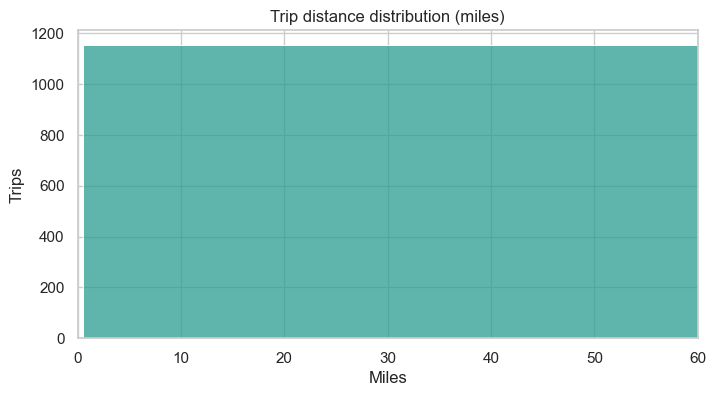

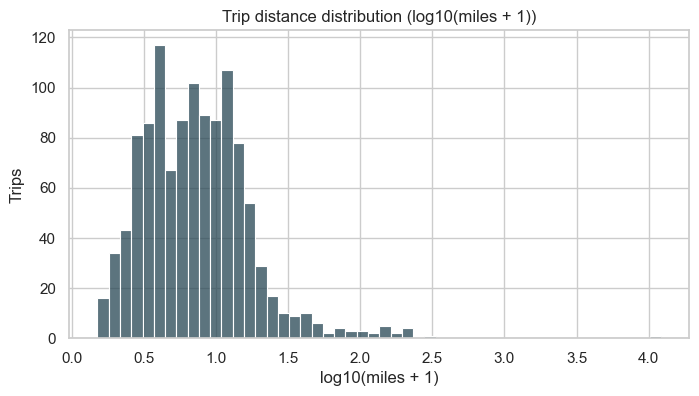

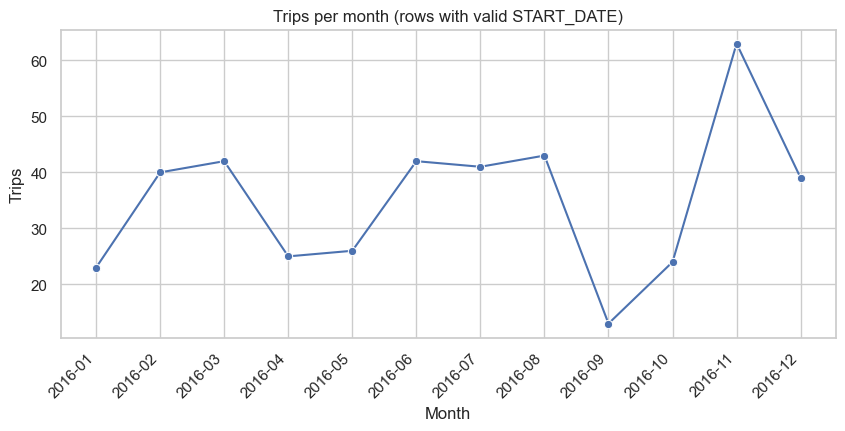

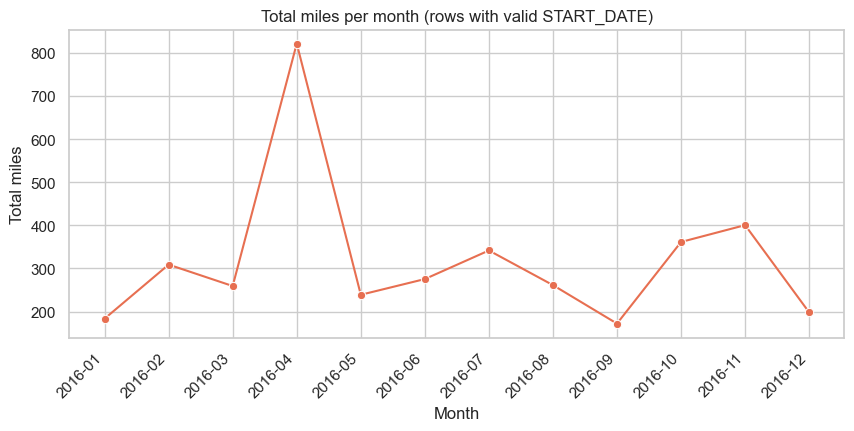

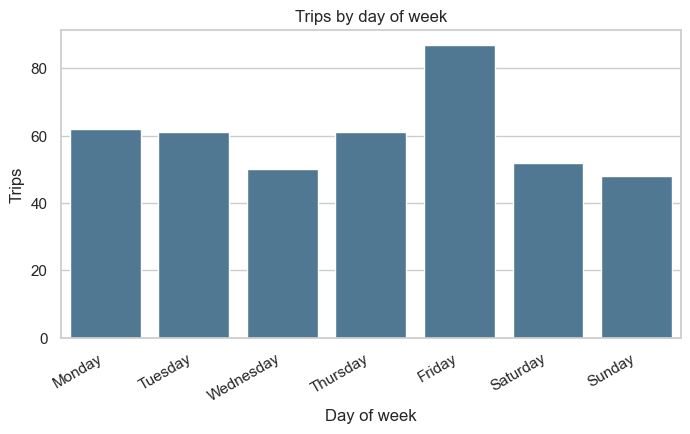

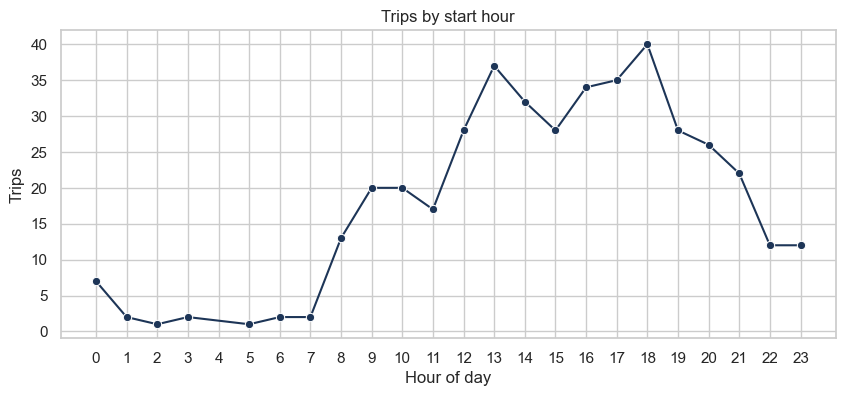

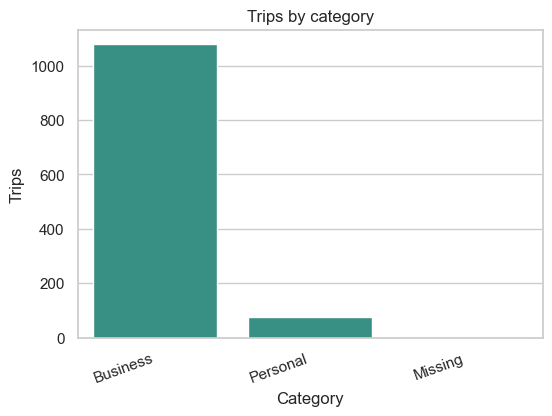

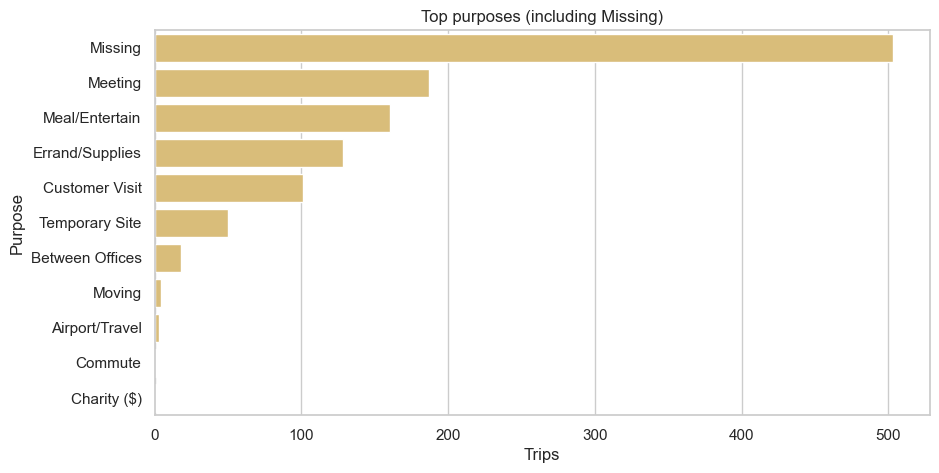

In [8]:
# Visualizations: distributions, time patterns, and category/purpose breakdowns
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Miles distribution (log scale helps with long tail)
plt.figure(figsize=(8,4))
sns.histplot(uber_df['MILES'], bins=60, color='#2a9d8f')
plt.title('Trip distance distribution (miles)')
plt.xlabel('Miles')
plt.ylabel('Trips')
plt.xlim(0, 60)
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(np.log10(uber_df['MILES'] + 1), bins=50, color='#264653')
plt.title('Trip distance distribution (log10(miles + 1))')
plt.xlabel('log10(miles + 1)')
plt.ylabel('Trips')
plt.show()

# Monthly trips and miles
monthly_agg_sorted = monthly_agg.sort_values('start_month')
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly_agg_sorted, x='start_month', y='trips', marker='o')
plt.title('Trips per month (rows with valid START_DATE)')
plt.xlabel('Month')
plt.ylabel('Trips')
plt.xticks(rotation=45, ha='right')
plt.show()

plt.figure(figsize=(10,4))
sns.lineplot(data=monthly_agg_sorted, x='start_month', y='total_miles', marker='o', color='#e76f51')
plt.title('Total miles per month (rows with valid START_DATE)')
plt.xlabel('Month')
plt.ylabel('Total miles')
plt.xticks(rotation=45, ha='right')
plt.show()

# Day of week and hour patterns
plt.figure(figsize=(8,4))
sns.barplot(data=dow_agg, x='start_dayofweek', y='trips', color='#457b9d')
plt.title('Trips by day of week')
plt.xlabel('Day of week')
plt.ylabel('Trips')
plt.xticks(rotation=30, ha='right')
plt.show()

plt.figure(figsize=(10,4))
sns.lineplot(data=hour_agg, x='start_hour', y='trips', marker='o', color='#1d3557')
plt.title('Trips by start hour')
plt.xlabel('Hour of day')
plt.ylabel('Trips')
plt.xticks(range(0,24))
plt.show()

# Category and purpose
plt.figure(figsize=(6,4))
cat_counts = uber_df['CATEGORY'].fillna('Missing').value_counts().reset_index()
cat_counts.columns = ['CATEGORY','count']
sns.barplot(data=cat_counts, x='CATEGORY', y='count', color='#2a9d8f')
plt.title('Trips by category')
plt.xlabel('Category')
plt.ylabel('Trips')
plt.xticks(rotation=20, ha='right')
plt.show()

plt.figure(figsize=(10,5))
purpose_counts = uber_df['PURPOSE'].fillna('Missing').value_counts().head(12).reset_index()
purpose_counts.columns = ['PURPOSE','count']
sns.barplot(data=purpose_counts, y='PURPOSE', x='count', color='#e9c46a')
plt.title('Top purposes (including Missing)')
plt.xlabel('Trips')
plt.ylabel('Purpose')
plt.show()